In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import fsolve

## Parámetros del sistema y configuración de simulación

In [2]:
# Tank cross-sectional areas [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Outlet orifice areas [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Pump flow constants [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Flow division parameters between upper and lower tanks
gamma1, gamma2 = 0.70, 0.60

# Constant gravitational acceleration [cm/s^2]
g = 981.0

# Time configuration and integration step
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Initial conditions for the levels of the four tanks [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Standard deviation of Gaussian noise for inputs and outputs
noise_input_std = 0.1
noise_output_std = 0.1

# Duration of steps for the excitation signal
t_change_min = 50
t_change_max = 50

# Voltage operating limits for the water pumps
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

El sistema se describe mediante el siguiente conjunto de ecuaciones acopladas:

$$\frac{dh_1}{dt} = -\frac{a_1}{A_1} \sqrt{2gh_1} + \frac{a_3}{A_1} \sqrt{2gh_3} + \frac{\gamma_1 k_1}{A_1} v_1$$
$$\frac{dh_2}{dt} = -\frac{a_2}{A_2} \sqrt{2gh_2} + \frac{a_4}{A_2} \sqrt{2gh_4} + \frac{\gamma_2 k_2}{A_2} v_2$$
$$\frac{dh_3}{dt} = -\frac{a_3}{A_3} \sqrt{2gh_3} + \frac{(1 - \gamma_2) k_2}{A_3} v_2$$
$$\frac{dh_4}{dt} = -\frac{a_4}{A_4} \sqrt{2gh_4} + \frac{(1 - \gamma_1) k_1}{A_4} v_1$$


In [3]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Unpack levels for the four tanks
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Numerical protection to avoid square roots of negative values
    h_safe = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_safe

    # Get input voltages at time t
    v1, v2 = u_func(t)

    # Mass balance for lower tanks with inflow from upper tanks
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Mass balance for upper tanks fed by divided flow
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Return state derivatives for the integrator
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [4]:
# Random number generator configuration with a fixed seed
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Initialization of indexes for signal level changes
t_change_indexes = []
curr_idx = 0

# Generation of random duration intervals for the steps
while curr_idx < n:
    t_change_indexes.append(curr_idx)

    # Calculation of step duration in seconds and its equivalent in steps
    duration_seg = rng_stream.uniform(t_change_min, t_change_max)
    step_sequences = int(duration_seg / dt)
    curr_idx += step_sequences

# Generation of random amplitudes for the voltages of both pumps
steps_values = rng_stream.uniform(V_min, V_max, size=(len(t_change_indexes), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [5]:
# Initialization of the matrix for the ideal input signal (no noise)
u_ideal = np.zeros((n, 2))

# Construction of the piecewise constant signal based on change indexes
for i in range(len(t_change_indexes)):
    idx_start = t_change_indexes[i]

    # Definition of the upper limit for the current interval
    if i == len(t_change_indexes) - 1:
        idx_end = n
    else:
        idx_end = t_change_indexes[i+1]

    # Assignment of voltages v1 and v2 for the defined time segment
    u_ideal[idx_start:idx_end, :] = steps_values[i]

# Generation of Gaussian white noise to simulate actuator uncertainty
noise_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Application of noise and clipping the signal to physical operating limits
u_noisy = u_ideal + noise_input
u_noisy = np.clip(u_noisy, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [6]:
# Creation of interpolation function for the noisy input
u_fun = interp1d(t, u_noisy, axis=0, kind='linear', fill_value='extrapolate')

# Definition of the wrapper to integrate the model with fixed parameters
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Solving the system of differential equations using RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extraction and organization of the simulated level trajectories
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [7]:
# Generation of Gaussian white noise for the sensors of the four tanks
noise_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
noise_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
noise_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
noise_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Application of noise to simulated levels with lower physical limit restriction
h1_noisy = np.maximum(h1_sim + noise_h1, 0.0)
h2_noisy = np.maximum(h2_sim + noise_h2, 0.0)
h3_noisy = np.maximum(h3_sim + noise_h3, 0.0)
h4_noisy = np.maximum(h4_sim + noise_h4, 0.0)

# Consolidation of time vectors, noisy inputs, and measured levels
t_full = t_out
u_full = u_noisy
h1_full = h1_noisy
h2_full = h2_noisy
h3_full = h3_noisy
h4_full = h4_noisy

# Definition of the total dimension for the training dataset
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

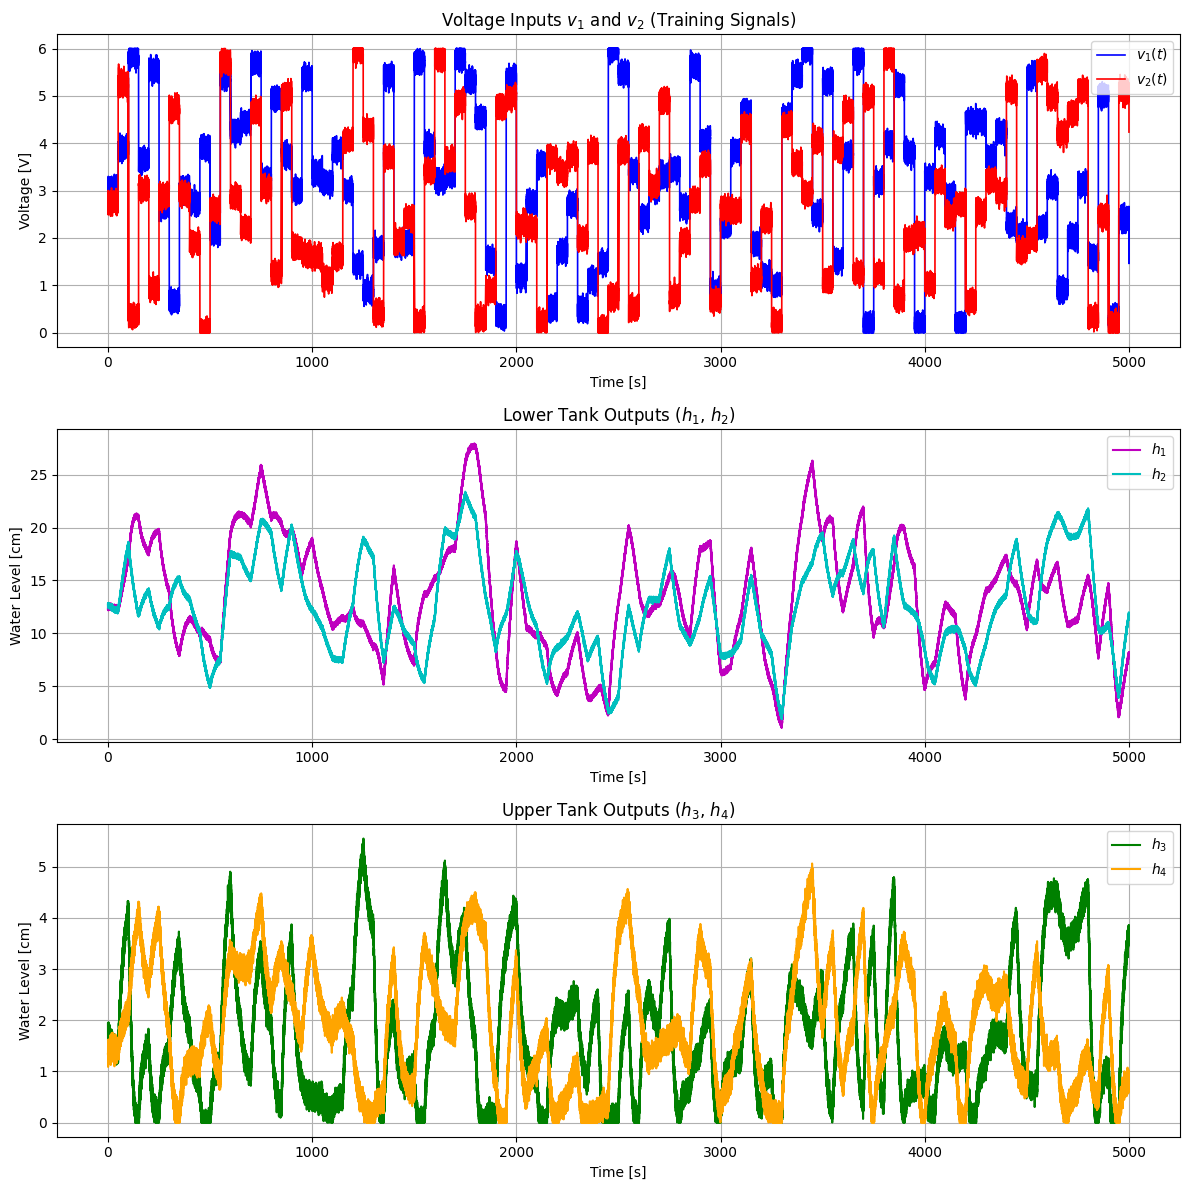

In [8]:
# Creation of the canvas for training signal visualization
plt.figure(figsize=(12, 12))

# Visualization of the input voltages applied to the pumps
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title('Voltage Inputs $v_1$ and $v_2$ (Training Signals)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualization of the dynamic response of the lower tanks
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Lower Tank Outputs ($h_1$, $h_2$)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualization of the dynamic response of the upper tanks
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Upper Tank Outputs ($h_3$, $h_4$)')
plt.legend(loc='upper right')
plt.grid(True)

# Layout adjustment and subplots display
plt.tight_layout()
plt.show()

In [9]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Level estimation
    P = np.zeros(n)          # Error covariance
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Prediction
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q

        # Update
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus
        
    return x_hat

# Application with tuning parameters (Q: process, R: sensor)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

In [10]:
from scipy.optimize import fsolve

# Define operating voltage
v1_op = 2.00
v2_op = 4.00
u_op = np.array([v1_op, v2_op])

# Analytical calculation of the equilibrium point (h_op)
h3_op = ((1 - gamma2) * k2 * v2_op / a3)**2 / (2 * g)
h4_op = ((1 - gamma1) * k1 * v1_op / a4)**2 / (2 * g)
h1_op = (gamma1 * k1 * v1_op + a3 * np.sqrt(2 * g * h3_op))**2 / (a1**2 * 2 * g)
h2_op = (gamma2 * k2 * v2_op + a4 * np.sqrt(2 * g * h4_op))**2 / (a2**2 * 2 * g)

h_op = np.array([h1_op, h2_op, h3_op, h4_op])

print(f"Operating point Voltage: v1={v1_op:.2f}V, v2={v2_op:.2f}V")
print(f"Calculated equilibrium levels: h1={h_op[0]:.2f}, h2={h_op[1]:.2f}, h3={h_op[2]:.2f}, h4={h_op[3]:.2f} [cm]")

Operating point Voltage: v1=2.00V, v2=4.00V
Calculated equilibrium levels: h1=10.16, h2=15.81, h3=2.90, h4=0.63 [cm]


In [11]:
# Characteristic discharge times based on equilibrium points
T1 = (A1 / a1) * np.sqrt(2 * h_op[0] / g)
T2 = (A2 / a2) * np.sqrt(2 * h_op[1] / g)
T3 = (A3 / a3) * np.sqrt(2 * h_op[2] / g)
T4 = (A4 / a4) * np.sqrt(2 * h_op[3] / g)

print(f"T1: {T1:.2f}, T2: {T2:.2f}, T3: {T3:.2f}, T4: {T4:.2f}")

# State matrix A representing linearized system dynamics
A = np.array([
    [-1/T1,     0,      (A3/(A1*T3)),      0],
    [0,      -1/T2,          0,       (A4/(A2*T4))],
    [0,         0,        -1/T3,           0],
    [0,         0,           0,        -1/T4]
])

# Input matrix B representing the effect of pump voltages
B = np.array([
    [(gamma1 * k1 / A1),       0],
    [0,                 (gamma2 * k2 / A2)],
    [0,           ((1 - gamma2) * k2 / A3)],
    [((1 - gamma1) * k1 / A4),       0]
])

# Identity output matrix C assuming all levels are measured
C = np.eye(4)

# Zero direct transmission matrix D
D = np.zeros((4, 2))

print("Matriz A (Dinámica de estados):")
print(np.round(A, 4))
print("\nMatriz B (Efecto de las bombas):")
print(np.round(B, 4))

T1: 56.74, T2: 100.78, T3: 30.35, T4: 20.06
Matriz A (Dinámica de estados):
[[-0.0176  0.      0.033   0.    ]
 [ 0.     -0.0099  0.      0.0499]
 [ 0.      0.     -0.033   0.    ]
 [ 0.      0.      0.     -0.0499]]

Matriz B (Efecto de las bombas):
[[0.0832 0.    ]
 [0.     0.0628]
 [0.     0.0479]
 [0.0312 0.    ]]


In [12]:
# Linearized ODE system function using state deviations
def linear_ode_system(t, delta_h, u_func, A, B, u_op):
    # Current input acquisition and deviation calculation
    u_t = u_func(t)
    delta_u = u_t - u_op

    # Current absolute level calculation
    h_actual = delta_h + h_op

    # Linear state equation: d(delta_h)/dt = A * delta_h + B * delta_u
    ddelta_h_dt = A @ delta_h + B @ delta_u
            
    return ddelta_h_dt

# Initial conditions for the linear model as deviations from equilibrium
delta_h0 = h0 - h_op

# Integration of the linearized state-space model
sol_linear = solve_ivp(
    fun=lambda tt, hh: linear_ode_system(tt, hh, u_fun, A, B, u_op),
    t_span=[t[0], t[-1]],
    y0=delta_h0,
    method='RK45',
    t_eval=t
)

# Total level reconstruction by adding the equilibrium point to the deviations
h_linear_sim = sol_linear.y.T + h_op

In [13]:
# Helper function to compute RMSE and VAF between real and predicted signals
def calculate_metrics(real, pred):
    rmse = np.sqrt(np.mean((real - pred)**2))
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)
    return rmse, vaf

# Metrics calculation for each tank by comparing nonlinear simulation with linear model
rmse1, vaf1 = calculate_metrics(h1_full, h_linear_sim[:, 0])
rmse2, vaf2 = calculate_metrics(h2_full, h_linear_sim[:, 1])
rmse3, vaf3 = calculate_metrics(h3_full, h_linear_sim[:, 2])
rmse4, vaf4 = calculate_metrics(h4_full, h_linear_sim[:, 3])

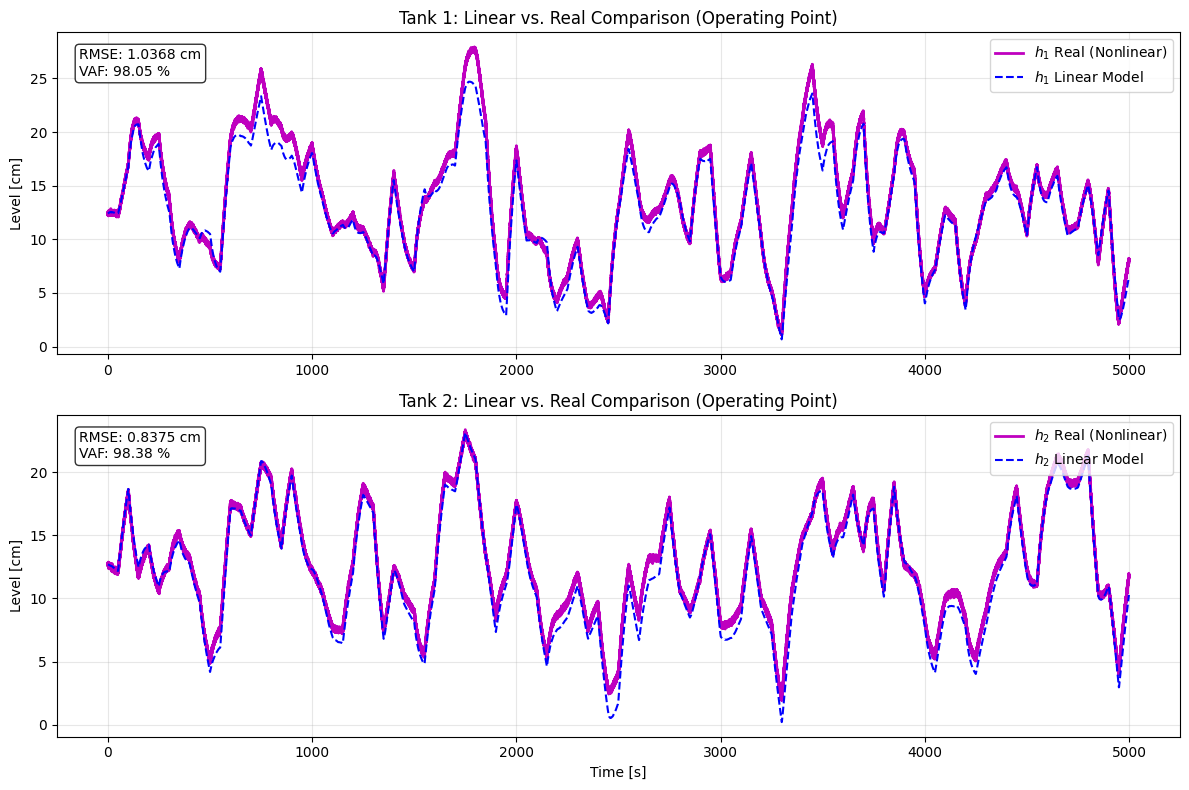

In [14]:
# --- PIECE NO. 1: LOWER TANKS ---
plt.figure(figsize=(12, 8))

# Tank 1: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 1)
plt.plot(t_full, h1_full, 'm', linewidth=2, label='$h_1$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 0], 'b--', linewidth=1.5, label='$h_1$ Linear Model')
plt.ylabel('Level [cm]')
plt.title('Tank 1: Linear vs. Real Comparison (Operating Point)')
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tank 2: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 2)
plt.plot(t_full, h2_full, 'm', linewidth=2, label='$h_2$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 1], 'b--', linewidth=1.5, label='$h_2$ Linear Model')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.title('Tank 2: Linear vs. Real Comparison (Operating Point)')
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Classical Linearization data structuring for lower tanks
data_linear_inf = {
    'Tiempo [s]': t_full.flatten(),
    # Real level (reference)
    'h1_Real [cm]': h1_full.flatten(),
    'h2_Real [cm]': h2_full.flatten(),
    # Classical Linear Model prediction based on Jacobians/Operating Point
    'h1_Classical [cm]': h_linear_sim[:, 0].flatten(),
    'h2_Classical [cm]': h_linear_sim[:, 1].flatten()
}

# DataFrame creation for lower tank results
df_linear_inf = pd.DataFrame(data_linear_inf)

# Exporting data to CSV format
nombre_linear_inf_csv = "comparacion_linealizacion_tanques_inferiores.csv"
df_linear_inf.to_csv(nombre_linear_inf_csv, index=False, sep=',', encoding='utf-8')

print(f"✅ Linearization file (Lower Tanks) saved as: {nombre_linear_inf_csv}")

✅ Linearization file (Lower Tanks) saved as: comparacion_linealizacion_tanques_inferiores.csv


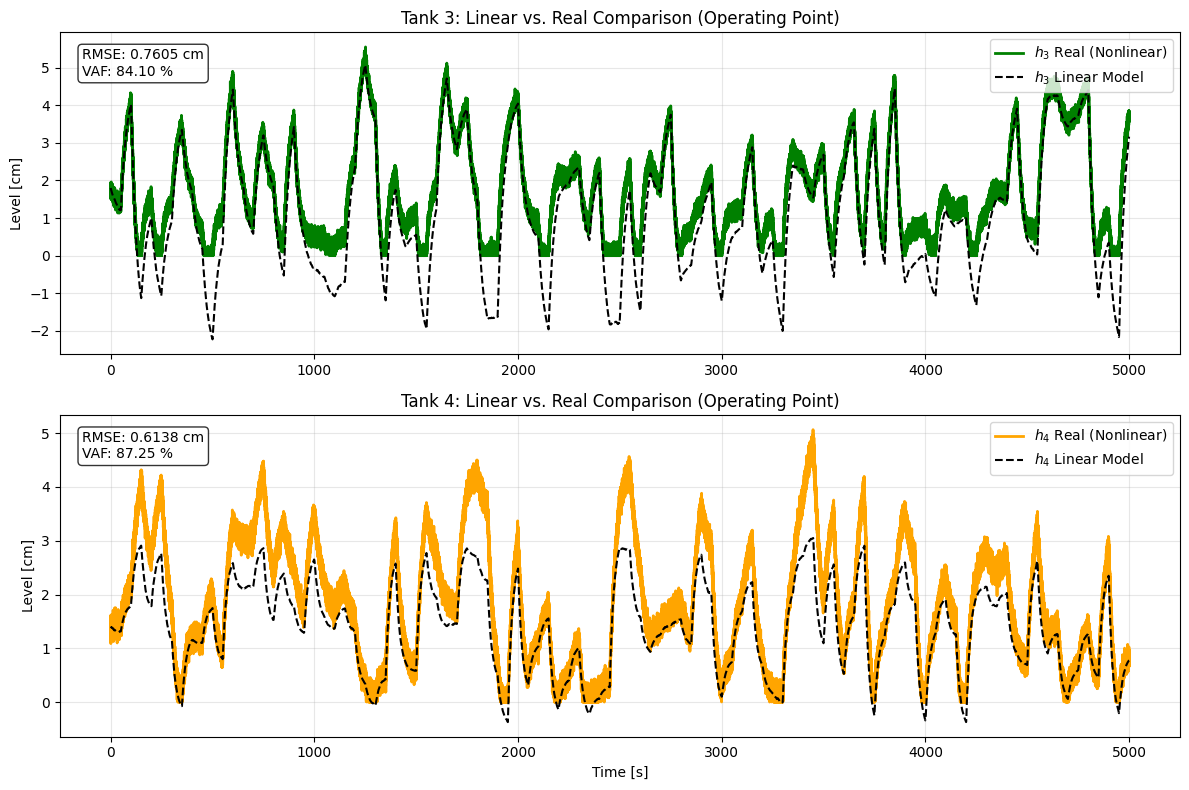

In [16]:
# --- PIECE NO. 2: UPPER TANKS ---
plt.figure(figsize=(12, 8))

# Tank 3: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 1)
plt.plot(t_full, h3_full, 'g', linewidth=2, label='$h_3$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 2], 'k--', linewidth=1.5, label='$h_3$ Linear Model')
plt.ylabel('Level [cm]')
plt.title('Tank 3: Linear vs. Real Comparison (Operating Point)')
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tank 4: Linear vs. Real comparison and metrics
plt.subplot(2, 1, 2)
plt.plot(t_full, h4_full, 'orange', linewidth=2, label='$h_4$ Real (Nonlinear)')
plt.plot(t_full, h_linear_sim[:, 3], 'k--', linewidth=1.5, label='$h_4$ Linear Model')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.title('Tank 4: Linear vs. Real Comparison (Operating Point)')
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Classical Linearization data structuring for upper tanks
data_linear_sup = {
    'Tiempo [s]': t_full.flatten(),
    # Real levels (Physical reference)
    'h3_Real [cm]': h3_full.flatten(),
    'h4_Real [cm]': h4_full.flatten(),
    # Classical Linear Model prediction for consistency with IEEE labels
    'h3_Classical [cm]': h_linear_sim[:, 2].flatten(),
    'h4_Classical [cm]': h_linear_sim[:, 3].flatten()
}

# DataFrame creation for upper tank results
df_linear_sup = pd.DataFrame(data_linear_sup)

# Exporting data to CSV format
nombre_linear_sup_csv = "comparacion_linealizacion_tanques_superiores.csv"
df_linear_sup.to_csv(nombre_linear_sup_csv, index=False, sep=',', encoding='utf-8')

print(f"✅ Linearization file (Upper Tanks) saved as: {nombre_linear_sup_csv}")

✅ Linearization file (Upper Tanks) saved as: comparacion_linealizacion_tanques_superiores.csv
